## Imports

In [1]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

import neuro_fuzzy_toolbox as nft

In [2]:
import pandas as pd
import numpy as np
#import matplotlib.pyplot as plt
#import seaborn as sns

In [3]:
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler
)
from sklearn.model_selection import train_test_split

In [4]:
from ucimlrepo import fetch_ucirepo

## Data

In [5]:
auto_mpg = fetch_ucirepo(id=9)

X = auto_mpg.data.features 
y = auto_mpg.data.targets

In [6]:
X = X.fillna(X.mean()).astype(np.float32)
y = y.astype(np.float32)

In [7]:
X

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,307.0,8.0,130.0,3504.0,12.0,70.0,1.0
1,350.0,8.0,165.0,3693.0,11.5,70.0,1.0
2,318.0,8.0,150.0,3436.0,11.0,70.0,1.0
3,304.0,8.0,150.0,3433.0,12.0,70.0,1.0
4,302.0,8.0,140.0,3449.0,10.5,70.0,1.0
...,...,...,...,...,...,...,...
393,140.0,4.0,86.0,2790.0,15.6,82.0,1.0
394,97.0,4.0,52.0,2130.0,24.6,82.0,2.0
395,135.0,4.0,84.0,2295.0,11.6,82.0,1.0
396,120.0,4.0,79.0,2625.0,18.6,82.0,1.0


In [8]:
#sns.pairplot(X)
#plt.show()

In [9]:
#for column in X.columns:
#    plt.figure(figsize=(6, 4))
#    sns.scatterplot(x=X[column], y=y.squeeze(), alpha=0.7)
#    plt.xlabel(column)
#    plt.ylabel('Target')
#    plt.title(f'{column} vs Target')
#    plt.grid(True)
#    plt.show()

In [10]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float32
 1   cylinders     398 non-null    float32
 2   horsepower    398 non-null    float32
 3   weight        398 non-null    float32
 4   acceleration  398 non-null    float32
 5   model_year    398 non-null    float32
 6   origin        398 non-null    float32
dtypes: float32(7)
memory usage: 11.0 KB


In [11]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

In [12]:
#scaler_x = MinMaxScaler(feature_range=(-1, 1))
scaler_x = StandardScaler()

x_train = scaler_x.fit_transform(x_train)

x_test = scaler_x.transform(x_test)

In [13]:
#scaler_y = MinMaxScaler(feature_range=(-1, 1))
scaler_y = StandardScaler()

y_train = scaler_y.fit_transform(y_train)

y_test = scaler_y.transform(y_test)

In [14]:
#scaled_df = pd.DataFrame(x_train, columns=X.columns)
#sns.pairplot(scaled_df)
#plt.show()

In [15]:
#for column in scaled_df.columns:
#    plt.figure(figsize=(6, 4))
#    sns.scatterplot(x=scaled_df[column], y=y_train.squeeze(), alpha=0.7)
#    plt.xlabel(column)
#    plt.ylabel('Target')
#    plt.title(f'{column} vs Target')
#    plt.grid(True)
#    plt.show()

In [16]:
x_train.shape, x_test.shape

((199, 7), (199, 7))

In [17]:
loader = data.DataLoader(
    data.TensorDataset(
        torch.from_numpy(x_train), 
        torch.from_numpy(y_train).squeeze()), 
    batch_size = 4, 
    shuffle = True)

x_train = loader.dataset.tensors[0]
y_train = loader.dataset.tensors[1]

x_test = torch.from_numpy(x_test)
y_test = torch.from_numpy(y_test).squeeze()

## Model & Training

In [18]:
#mf_distribution = [5, 5, 4, 5, 5, 4, 5] # R2=0.72
#mf_distribution = [4, 4, 3, 4, 4, 3, 4] # R2=0.73
mf_distribution = [3, 3, 2, 3, 3, 2, 3] # R2=0.87

In [19]:
model = nft.ANFIS(
    mf_distribution=mf_distribution,
    membership_function=nft.Gaussian_MF
)

In [20]:
model.init_premises(x_train)

In [21]:
model.init_consequents(x_train, y_train)

In [22]:
loss_fn = nn.functional.mse_loss

early_stopping = nft.EarlyStopping(patience=40)

In [23]:
optimizer = torch.optim.AdamW
params = {'lr': 0.001, 'weight_decay': 0.01}

trainer = nft.Basic_optimizer_training_algorithm(
    epochs=1000,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    validation=0.3,
    early_stopping=early_stopping
)

In [24]:
trainer(model, loader, verbose=True)

Epoch:    1/1000 - loss: 0.443893 - validation loss: 0.319564
Epoch:    2/1000 - loss: 0.369727 - validation loss: 0.263787
Epoch:    3/1000 - loss: 0.304212 - validation loss: 0.213086
Epoch:    4/1000 - loss: 0.262294 - validation loss: 0.181183
Epoch:    5/1000 - loss: 0.236600 - validation loss: 0.163096
Epoch:    6/1000 - loss: 0.216775 - validation loss: 0.149588
Epoch:    7/1000 - loss: 0.203574 - validation loss: 0.140194
Epoch:    8/1000 - loss: 0.192866 - validation loss: 0.133937
Epoch:    9/1000 - loss: 0.186575 - validation loss: 0.130049
Epoch:   10/1000 - loss: 0.180786 - validation loss: 0.127042
Epoch:   11/1000 - loss: 0.176022 - validation loss: 0.124691
Epoch:   12/1000 - loss: 0.171399 - validation loss: 0.122434
Epoch:   13/1000 - loss: 0.167741 - validation loss: 0.120170
Epoch:   14/1000 - loss: 0.163896 - validation loss: 0.118625
Epoch:   15/1000 - loss: 0.161015 - validation loss: 0.116848
Epoch:   16/1000 - loss: 0.158034 - validation loss: 0.115250
Epoch:  

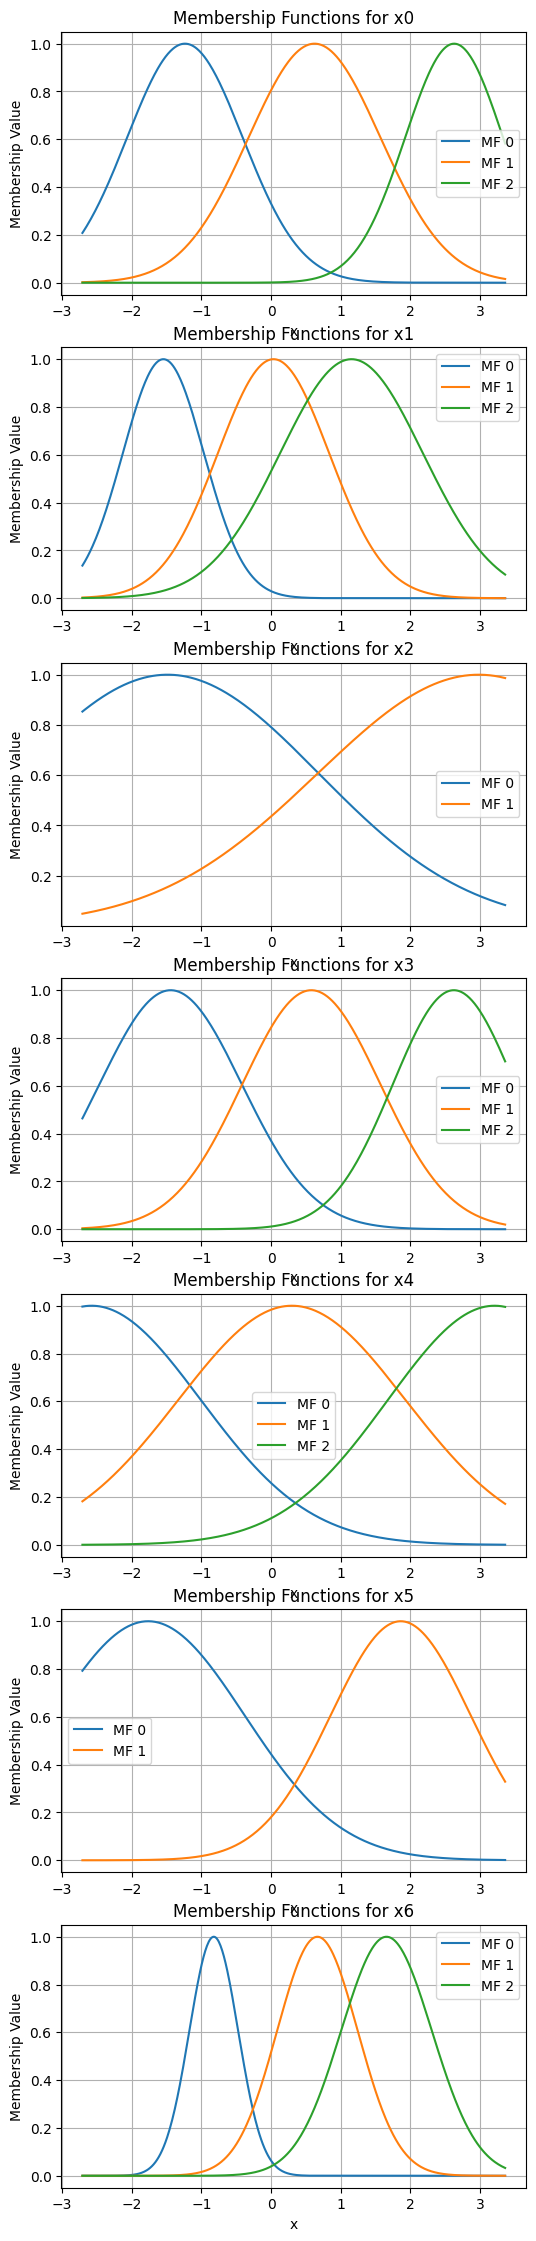

In [26]:
model.plot_premises(group_by_dim=True)

In [27]:
model.premises_structure

,mu (x0),sigma (x0),mu (x1),sigma (x1),mu (x2),sigma (x2),mu (x3),sigma (x3),mu (x4),sigma (x4),mu (x5),sigma (x5),mu (x6),sigma (x6)
MF 0,-1.234943,0.830340,-1.544446,0.581980,-1.483825,2.169488,-1.439824,1.021341,-2.573813,1.565487,-1.762973,1.383547,-0.821623,0.349946
MF 1,0.623860,0.947614,0.035419,0.798554,2.979205,2.310606,0.577859,0.991159,0.299646,1.628626,1.859752,1.004511,0.665636,0.578515
MF 2,2.626335,0.703303,1.154279,1.024529,NaN,NaN,2.622015,0.875260,3.205752,1.528871,NaN,NaN,1.656169,0.650602


In [28]:
test_measures = nft.get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.10888581722974777
RMSE: 0.32997849583625793
MAE: 0.2359192818403244
R2: 0.8944282531738281
MAPE: 15.73948860168457


In [29]:
train_measures = nft.get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.09457127004861832
RMSE: 0.3075244128704071
MAE: 0.2121758610010147
R2: 0.9054287075996399
MAPE: 0.6972066760063171
